## EDA

In [106]:
# Librerías principales
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\isabe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Cargar base de datos
df = pd.read_csv(r"C:\Users\isabe\OneDrive - Universidad Autónoma Latinoamericana\Escritorio\CD2T2\sgdata.csv")
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,single,67,university,124670,skilled employee / official,2
1,100000002,1,non-single (divorced / separated / married / w...,22,high school,150773,skilled employee / official,2
2,100000003,0,single,49,high school,89210,unemployed / unskilled,0
3,100000004,0,single,45,high school,171565,skilled employee / official,1
4,100000005,0,single,53,high school,149031,skilled employee / official,1


In [113]:
# Dimensiones del dataset
print(f"Filas y columnas: {df.shape}")

# Información general
df.info()


Filas y columnas: (2000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               2000 non-null   int64 
 1   Sex              2000 non-null   int64 
 2   Marital status   2000 non-null   object
 3   Age              2000 non-null   int64 
 4   Education        2000 non-null   object
 5   Income           2000 non-null   int64 
 6   Occupation       2000 non-null   object
 7   Settlement size  2000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 125.1+ KB


In [115]:
# Revisión de nulos
df.isnull().sum().sort_values(ascending=False)


ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

In [116]:
# Resumen estadístico de las variables numéricas
df.describe()


,ID,Sex,Age,Income,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,35.909000,120954.419000,0.739000
std,5.774946e+02,0.498272,11.719402,38108.824679,0.812533
min,1.000000e+08,0.000000,18.000000,35832.000000,0.000000
25%,1.000005e+08,0.000000,27.000000,97663.250000,0.000000
50%,1.000010e+08,0.000000,33.000000,115548.500000,1.000000
75%,1.000015e+08,1.000000,42.000000,138072.250000,1.000000
max,1.000020e+08,1.000000,76.000000,309364.000000,2.000000


In [117]:
# Detectar variables categóricas
cat_vars = df.select_dtypes(include=['object']).columns
print(f"Variables categóricas: {list(cat_vars)}")

# Conteo de categorías para cada variable categórica
for var in cat_vars:
    print(f"\n{var}:\n{df[var].value_counts()}")


Variables categóricas: ['Marital status', 'Education', 'Occupation']

Marital status:
Marital status
single                                                   1007
non-single (divorced / separated / married / widowed)     993
Name: count, dtype: int64

Education:
Education
high school        1386
university          291
other / unknown     287
graduate school      36
Name: count, dtype: int64

Occupation:
Occupation
skilled employee / official                                         1113
unemployed / unskilled                                               633
management / self-employed / highly qualified employee / officer     254
Name: count, dtype: int64


C:\Users\isabe\AppData\Local\Temp\ipykernel_10352\2404004167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Estado_Civil', data=df, palette='pastel')


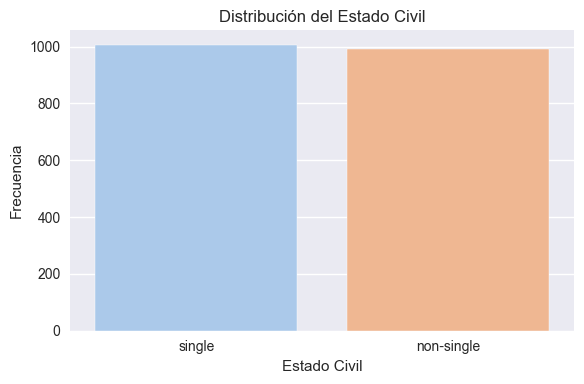

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que los valores están como booleanos
df['Estado_Civil'] = df['Marital status_single'].map({True: 'single', False: 'non-single'})

# Gráfico
plt.figure(figsize=(6, 4))
sns.countplot(x='Estado_Civil', data=df, palette='pastel')
plt.title('Distribución del Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()



In [160]:
print(df['Marital status_single'].value_counts())


Marital status_single
True     1007
False     993
Name: count, dtype: int64


In [120]:
# Variables categóricas
cat_vars = df.select_dtypes(include=['object']).columns
print(f"Variables categóricas: {list(cat_vars)}")

# Crear etiqueta de Sexo
df['Sexo_label'] = df['Sex'].map({0: 'Femenino', 1: 'Masculino'})


Variables categóricas: ['Marital status', 'Education', 'Occupation']


In [ ]:
# Codificar las etiquetas (si son categóricas)
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)

for name, model in models.items():
    # Predecir
    y_pred = model.predict(X_test)
    y_pred_encoded = le.transform(y_pred)

    # Correlación entre predicciones y valores reales
    corr, _ = pearsonr(y_test_encoded, y_pred_encoded)
    print(f"📊 Correlación de Pearson para {name}: {corr:.4f}")



📊 Correlación de Pearson para KNN: 0.2356
📊 Correlación de Pearson para Logistic Regression: 0.3736
📊 Correlación de Pearson para Decision Tree: 0.2402


In [121]:
# Mostrar conteo de cada categoría
for var in cat_vars:
    print(f"\nConteo de categorías en {var}:")
    print(df[var].value_counts())


Conteo de categorías en Marital status:
Marital status
single                                                   1007
non-single (divorced / separated / married / widowed)     993
Name: count, dtype: int64

Conteo de categorías en Education:
Education
high school        1386
university          291
other / unknown     287
graduate school      36
Name: count, dtype: int64

Conteo de categorías en Occupation:
Occupation
skilled employee / official                                         1113
unemployed / unskilled                                               633
management / self-employed / highly qualified employee / officer     254
Name: count, dtype: int64


C:\Users\isabe\AppData\Local\Temp\ipykernel_10352\1070641603.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education', data=df, palette='muted')


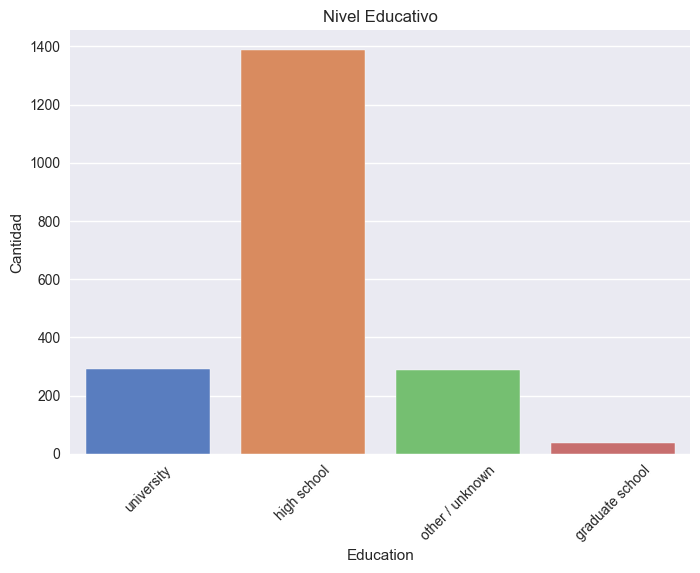

In [124]:
sns.countplot(x='Education', data=df, palette='muted')
plt.title('Nivel Educativo')
plt.xlabel('Education')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()


C:\Users\isabe\AppData\Local\Temp\ipykernel_10352\4141980252.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Occupation', data=df, palette='coolwarm')


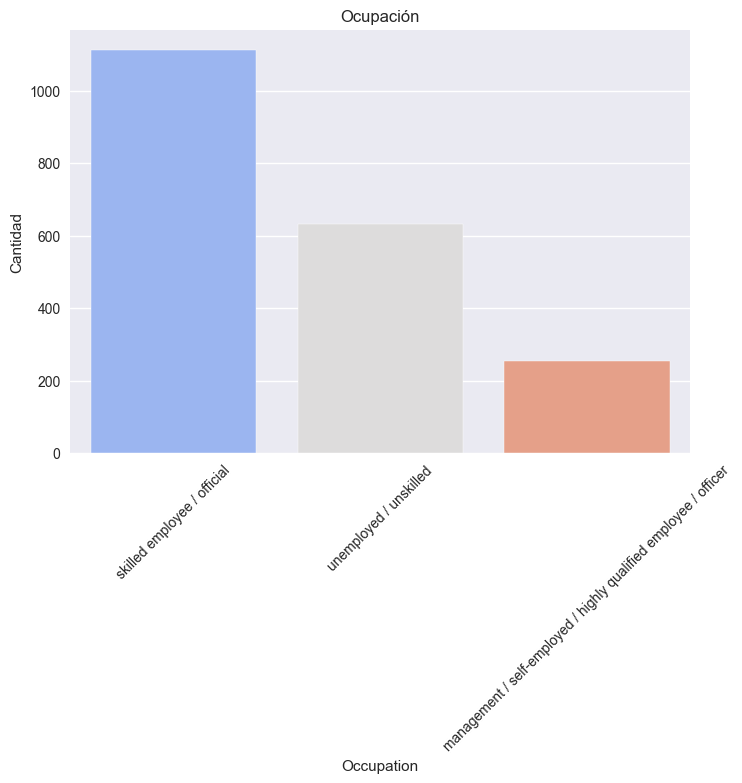

In [125]:
sns.countplot(x='Occupation', data=df, palette='coolwarm')
plt.title('Ocupación')
plt.xlabel('Occupation')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()


## PREPROCESAMIENTO Y MODELOS


In [141]:
# Crear variable categórica de ingreso
df['Income_cat'] = pd.qcut(df['Income'], q=3, labels=['low', 'middle', 'high'])

# Separar X e y
y = df['Income_cat']
X = df.drop(columns=['Income', 'Income_cat', 'ID'])

# Escalar variables numéricas
scaler = StandardScaler()
X[['Age', 'Settlement size']] = scaler.fit_transform(X[['Age', 'Settlement size']])

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [145]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score


In [131]:
# Agrupar en 3 clases: low, middle, high
df['Income_cat'] = pd.qcut(df['Income'], q=3, labels=['low', 'middle', 'high'])

# Actualizar variable objetivo
y = df['Income_cat']
X = df.drop(columns=['Income', 'Income_cat', 'ID'])


In [132]:
# Escalar las variables numéricas
scaler = StandardScaler()
num_cols = ['Age', 'Settlement size']
X[num_cols] = scaler.fit_transform(X[num_cols])

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [140]:
print(df.columns.tolist())


['ID', 'Age', 'Income', 'Settlement size', 'Sex_1', 'Marital status_single', 'Education_high school', 'Education_other / unknown', 'Education_university', 'Occupation_skilled employee / official', 'Occupation_unemployed / unskilled']


In [148]:
# Función de evaluación
from sklearn.metrics import accuracy_score

def evaluate_accuracy_model(model, features, target):
    y_pred = model.predict(features)
    acc = accuracy_score(target, y_pred)
    return acc


In [146]:
# Lista de modelos
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42)}

In [149]:
# Entrenar y evaluar
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Accuracy en test
    acc = evaluate_accuracy_model(model, X_test, y_test)

    # Validación cruzada (accuracy)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    # AUC macro
    y_test_bin = label_binarize(y_test, classes=['low', 'middle', 'high'])
    y_score = model.predict_proba(X_test)
    auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')

c:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\isabe\AppD

In [ ]:
 # Mostrar resultados
    print(f"🔹 Modelo: {name}")
    print(f"   ✅ Accuracy (test): {acc:.4f}")
    print(f"   🔁 Cross-val Accuracy (media): {cv_scores.mean():.4f}")
    print(f"   📈 AUC macro: {auc:.4f}")
    print("-" * 50)

🔹 Modelo: Decision Tree
   ✅ Accuracy (test): 0.5925
   🔁 Cross-val Accuracy (media): 0.5670
   📈 AUC macro: 0.3882
--------------------------------------------------


C:\Users\isabe\AppData\Local\Temp\ipykernel_10352\3406968988.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Correlación', data=corr_df, palette='mako')


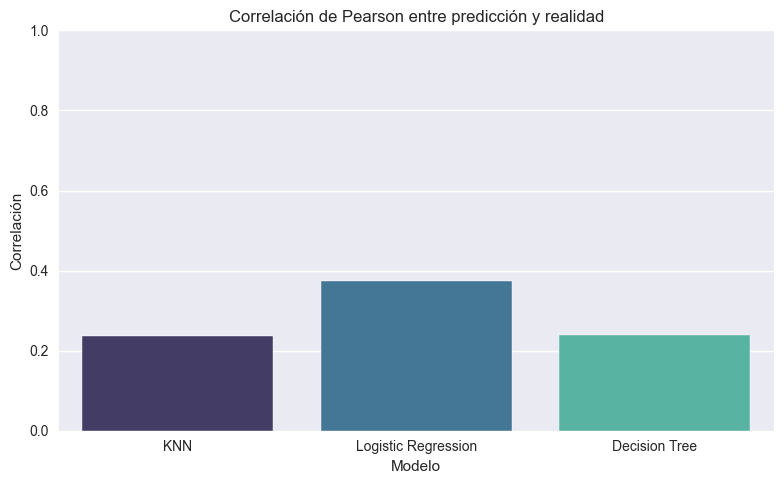

In [155]:
# Codificar etiquetas verdaderas
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)

# Almacenar correlaciones
correlations = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_encoded = le.transform(y_pred)
    corr, _ = pearsonr(y_test_encoded, y_pred_encoded)
    correlations[name] = corr

# Convertir a DataFrame
corr_df = pd.DataFrame(list(correlations.items()), columns=['Modelo', 'Correlación'])

# Graficar
plt.figure(figsize=(8, 5))
sns.barplot(x='Modelo', y='Correlación', data=corr_df, palette='mako')
plt.title('Correlación de Pearson entre predicción y realidad')
plt.ylim(0, 1)
plt.ylabel('Correlación')
plt.xlabel('Modelo')
plt.tight_layout()
plt.show()


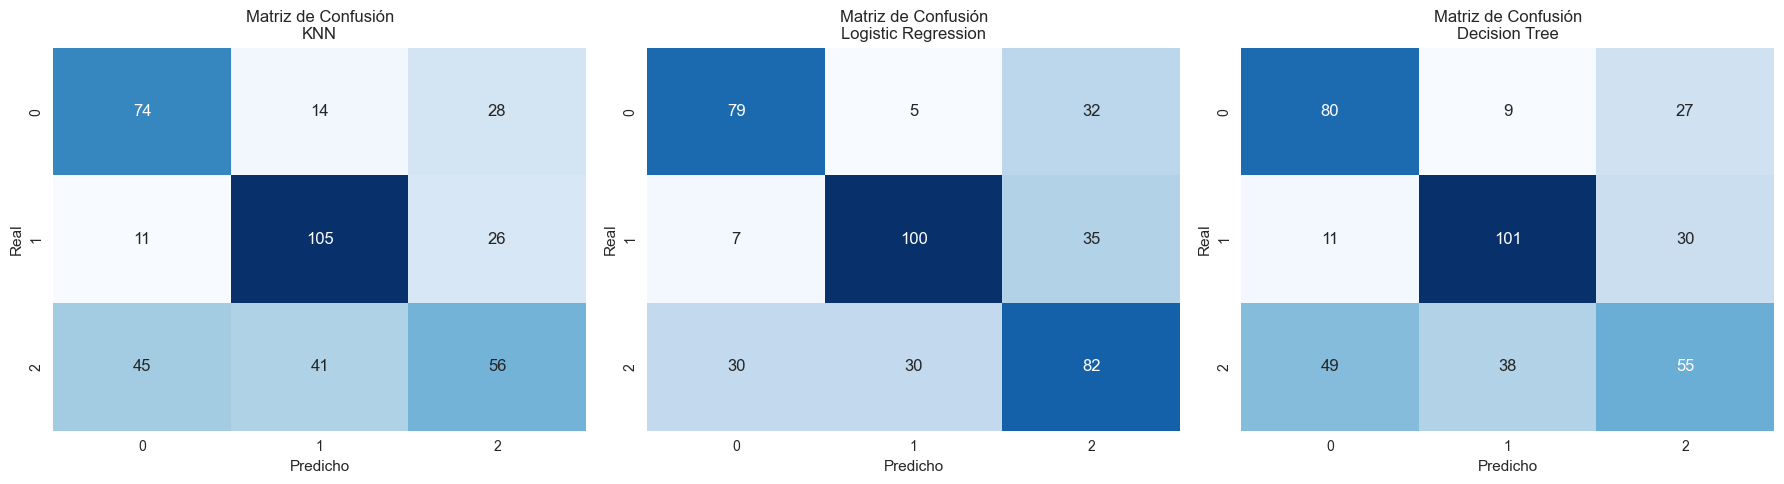

In [ ]:
# Preparar codificación de etiquetas
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)

# Configurar figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = list(models.keys())

for ax, name in zip(axes, model_names):
    model = models[name]
    y_pred = model.predict(X_test)
    y_pred_encoded = le.transform(y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred_encoded)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Matriz de Confusión\n{name}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()


c:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\isabe\AppD

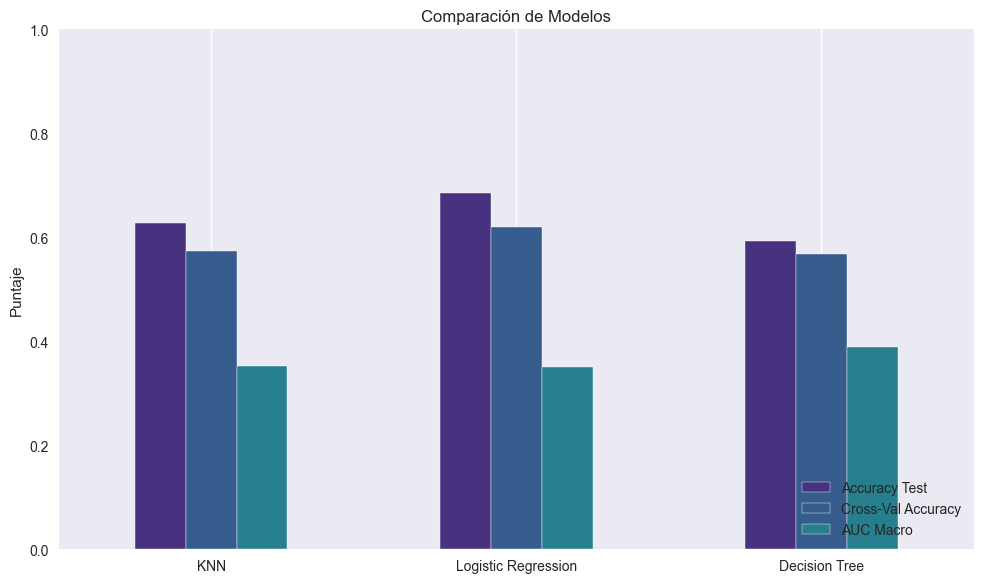

In [151]:
import matplotlib.pyplot as plt

# Diccionarios para almacenar métricas
accuracy_test = {}
accuracy_cv = {}
auc_macro = {}

# Evaluar todos los modelos
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Métricas
    acc = evaluate_accuracy_model(model, X_test, y_test)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    
    y_test_bin = label_binarize(y_test, classes=['low', 'middle', 'high'])
    y_score = model.predict_proba(X_test)
    auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
    
    # Guardar resultados
    accuracy_test[name] = acc
    accuracy_cv[name] = cv_scores.mean()
    auc_macro[name] = auc

# 🔹 Crear DataFrame para graficar
results_df = pd.DataFrame({
    'Accuracy Test': accuracy_test,
    'Cross-Val Accuracy': accuracy_cv,
    'AUC Macro': auc_macro
})

# 🔹 Graficar
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Modelos')
plt.ylabel('Puntaje')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
